# Exploração — Forecast Semana 1

Notebook de análise exploratória. A carga dos dados fica em `data_load.py`.

In [7]:
import sys
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
pasta_projeto = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(pasta_projeto) not in sys.path:
    sys.path.insert(0, str(pasta_projeto))

from data_load import carregar_dados_preparados,carregar_dados_preparados_2

In [9]:
from operator import index


df = carregar_dados_preparados()
df.head()

,data,Origem,Destino,volume_forecast,timestamp_geracao
0,2026-07-09,CD Regional,Loja A,559,2026-06-18 08:00:00
1,2026-07-09,CD Central,Loja B,483,2026-06-18 08:00:00
2,2026-07-09,CD Regional,Loja C,577,2026-06-18 08:00:00
3,2026-07-09,CD Regional,Loja D,682,2026-06-18 08:00:00
4,2026-07-09,CD Central,Loja E,471,2026-06-18 08:00:00


In [19]:
forecast = df['volume_forecast']
forecast.describe()

count     50.000000
mean     468.500000
std       90.051969
min      304.000000
25%      405.000000
50%      464.500000
75%      535.000000
max      690.000000
Name: volume_forecast, dtype: float64

In [23]:
min_forecast = df['volume_forecast'].min()
max_forecast = df['volume_forecast'].max()
amplitude_forecast = max_forecast - min_forecast
amplitude_forecast

np.int64(386)

In [24]:
df['volume_forecast'].skew()

np.float64(0.564217494990885)

<Axes: >

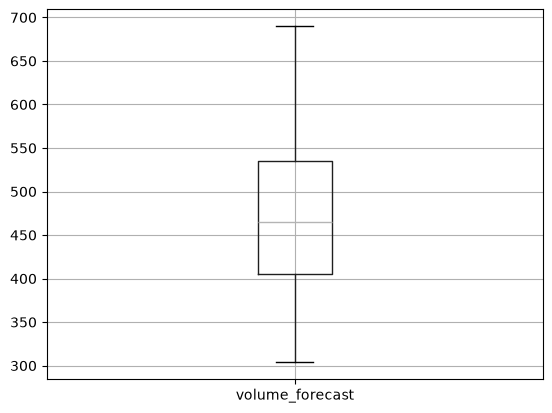

In [30]:
df.boxplot(column='volume_forecast')

In [7]:
df_2 = carregar_dados_preparados_2()
df_2.head()

,Data,Origem,Destino,Estado,Região,Volume
0,01/07/2026,CD Central,São Paulo,SP,Sudeste,701
1,01/07/2026,CD Central,Rio de Janeiro,RJ,Sudeste,200
2,01/07/2026,CD Central,Belo Horizonte,MG,Sudeste,593
3,01/07/2026,CD Central,Vitória,ES,Sudeste,723
4,01/07/2026,CD Regional Sul,Curitiba,PR,Sul,735


In [26]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50 entries, 0 to 49
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   data               50 non-null     str  
 1   Origem             50 non-null     str  
 2   Destino            50 non-null     str  
 3   volume_forecast    50 non-null     int64
 4   timestamp_geracao  50 non-null     str  
dtypes: int64(1), str(4)
memory usage: 2.1 KB


In [20]:
total_por_semana_mes = df.groupby('Destino')['volume_forecast'].sum().sort_values(ascending=False)
saidas = df['Destino'].count()
total_origens = df['Origem'].nunique()
total_destinos = df['Destino'].nunique()
total_destinos_por_origem = df.groupby('Origem')['Destino'].nunique()
print(total_origens,total_destinos,saidas,total_destinos_por_origem)



2 30 50 Origem
CD Central     19
CD Regional    20
Name: Destino, dtype: int64


In [27]:
central = set(df.loc[df["Origem"] == "CD Central", "Destino"])
regional = set(df.loc[df["Origem"] == "CD Regional", "Destino"])

print("Só Central:", len(central - regional))
print("Só Regional:", len(regional - central))
print("Nos dois:", len(central & regional))
print("Total único:", len(central | regional))

Só Central: 10
Só Regional: 11
Nos dois: 9
Total único: 30


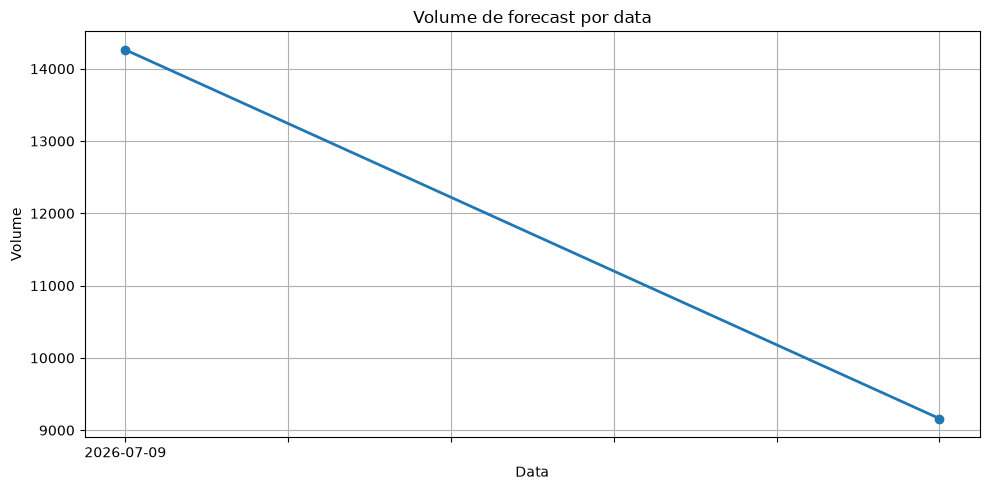

In [3]:
import matplotlib.pyplot as plt

total_por_semana_mes = df.groupby('data')['volume_forecast'].sum().sort_index()

total_por_semana_mes.plot(
    kind='line',
    figsize=(10, 5),
    marker='o',
    linewidth=2,
    title='Volume de forecast por data',
    xlabel='Data',
    ylabel='Volume',
    grid=True,
)
plt.tight_layout()
plt.show()